# ⚙️ Configuration

In [257]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from IPython.display import display, Markdown
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 📥 Load Data

In [258]:
df = pd.read_csv("/kaggle/input/datasets/shrutimechlearn/churn-modelling/Churn_Modelling.csv")

# 🤝 Helper Functions

In [259]:
def statistical_analysis(df): 
    # 1. General Overview Dashboard 
    display(Markdown("### 1. General Overview")) 
    overview = pd.DataFrame({ 
        'Metric': ['Rows', 'Columns', 'Duplicates', 'Total Missing Values'], 
        'Value': [df.shape[0], df.shape[1], df.duplicated().sum(), df.isnull().sum().sum()] 
    }).set_index('Metric') 
    display(overview) 
  
    # 2. Data Types & Missing Values (Combined) 
    display(Markdown("### 2. Data Types & Missing Values")) 
    info_df = pd.DataFrame({ 
        'Type': df.dtypes, 
        'Null Count': df.isnull().sum(), 
        'Null %': (df.isnull().sum() / len(df)) * 100 
    }) 
    # Sort by Null % so you see problems first 
    display(info_df.sort_values(by='Null Count', ascending=False)) 
  
    # 3. Descriptive Statistics (Transposed for readability) 
    display(Markdown("### 3. Numerical Statistics")) 
    # .T makes it easier to read if you have many columns 
    display(df.describe().T.style.background_gradient(cmap='Blues')) 
  
    # 4. Categorical Breakdown 
    display(Markdown("### 4. Categorical Value Counts")) 
    cat_columns = df.select_dtypes(include=['object', 'category']).columns.tolist() 
     
    
    if not cat_columns: 
        print("No categorical columns found.") 
    else: 
        for col in cat_columns: 
            display(Markdown(f"**--- {col} ---**")) 
            # Display as a horizontal bar chart inside the dataframe 
            val_counts = df[col].value_counts().to_frame() 
            display(val_counts.style.bar(color='#5fba7d', vmin=0)) 
             
    # 5. First 5 Rows 
    display(Markdown("### 5. Head")) 
    display(df.head())

In [260]:
def plot_distributions(df, columns=None, n_cols=3): 
    """ 
    Plots histograms with a Kernel Density Estimate (KDE) line for numerical columns. 
  
    Parameters: 
    - df: The dataframe 
    - columns: List of specific columns to plot (optional). If None, plots all numerical cols. 
    - n_cols: Number of graphs per row. 
    """ 
    # Auto-select numerical columns if none provided 
    if columns is None: 
        columns = df.select_dtypes(include=[np.number]).columns.tolist() 
  
    if len(columns) == 0: 
        print("No numerical columns to plot.") 
        return 
  
    # Calculate layout 
    n_rows = (len(columns) - 1) // n_cols + 1 
    plt.figure(figsize=(n_cols * 5, n_rows * 4)) 
  
    for i, col in enumerate(columns): 
        plt.subplot(n_rows, n_cols, i + 1) 
        sns.histplot(df[col], kde=True, color='teal', edgecolor='black') 
        plt.title(f'Distribution of {col}') 
        plt.xlabel(col) 
        plt.ylabel('Frequency') 
  
    plt.tight_layout() 
    plt.show()

In [261]:
def plot_outliers(df, columns=None, n_cols=4): 
    """ 
    Plots box plots for numerical columns to identify outliers. 
    """ 
    if columns is None: 
        columns = df.select_dtypes(include=[np.number]).columns.tolist() 
  
    if len(columns) == 0: 
        print("No numerical columns to plot.") 
        return 
  
    n_rows = (len(columns) - 1) // n_cols + 1 
    plt.figure(figsize=(n_cols * 4, n_rows * 3)) 
  
    for i, col in enumerate(columns): 
        plt.subplot(n_rows, n_cols, i + 1) 
        sns.boxplot(x=df[col], color='seagreen') 
        plt.title(f'Outliers in {col}') 
  
    plt.tight_layout() 
    plt.show() 

In [262]:
def plot_categoricals(df, columns=None, n_cols=3): 
    """ 
    Plots bar charts for categorical columns to show frequency. 
    """ 
    if columns is None: 
        # Select object types and categories 
        columns = df.select_dtypes(include=['object', 'category']).columns.tolist() 
  
    if len(columns) == 0: 
        print("No categorical columns to plot.") 
        return 
  
    n_rows = (len(columns) - 1) // n_cols + 1 
    plt.figure(figsize=(n_cols * 5, n_rows * 4)) 
  
    for i, col in enumerate(columns): 
        plt.subplot(n_rows, n_cols, i + 1) 
        sns.countplot(x=df[col], palette='magma') 
        plt.title(f'Counts of {col}') 
        plt.xticks(rotation=45) 
  
    plt.tight_layout() 
    plt.show() 

In [263]:
def plot_correlation(df, target_col=None): 
    """ 
    Plots a heatmap of correlations between numerical features. 
    If target_col is provided, prints the correlation of features with the target. 
    """ 
    # Select only numerical columns for correlation 
    numeric_df = df.select_dtypes(include=[np.number]) 
  
    if numeric_df.empty: 
        print("No numerical data for correlation.") 
        return 
  
    plt.figure(figsize=(15, 12)) 
    corr = numeric_df.corr() 
  
    # # Mask the upper triangle (since it's a mirror image) 
    # mask = np.triu(np.ones_like(corr, dtype=bool)) 
  
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', 
                linewidths=0.5, vmin=-1, vmax=1) 
    plt.title('Correlation Matrix Heatmap') 
    plt.show() 
  
    if target_col and target_col in numeric_df.columns: 
        print(f"\n--- Correlation with Target: {target_col} ---") 
        target_corr = corr[target_col].sort_values(ascending=False) 
        print(target_corr) 

In [264]:
def plot_feature_vs_target(df, target, isClassification, feature_cols=None): 
    """ 
    Plots relationships between features and the target. 
    - If target is Categorical (Classification): Uses Box Plots (Numerical Feature vs Target Class) 
    - If target is Numerical (Regression): Uses Scatter Plots (Numerical Feature vs Target Value) 
    """ 
    if feature_cols is None: 
        # Default to top 5 numerical columns 
        feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()[:5] 
  
    # Determine problem type based on target uniqueness 
    is_classification = isClassification 
  
    plt.figure(figsize=(15, 4 * len(feature_cols))) 
  
    for i, col in enumerate(feature_cols): 
        if col == target: continue 
  
        plt.subplot(len(feature_cols), 1, i + 1) 
  
        if is_classification: 
            # Classification: Box Plot separating classes 
            sns.boxplot(data=df, x=target, y=col, palette='Set2') 
            plt.title(f'{col} distribution by {target}') 
        else: 
            sns.scatterplot(data=df, x=col, y=target, alpha=0.6) 
            plt.title(f'{col} vs {target}') 
  
    plt.tight_layout() 
    plt.show() 

# ⚠️ Drop Unnecessary Columns

In [265]:
df = df.drop(columns=[
    "RowNumber","CustomerId","Surname"
])

# 📊 EDA

In [266]:
statistical_analysis(df)

### 1. General Overview

,Value
Metric,
Rows,10000
Columns,11
Duplicates,0
Total Missing Values,0


### 2. Data Types & Missing Values

,Type,Null Count,Null %
CreditScore,int64,0,0.0
Geography,object,0,0.0
Gender,object,0,0.0
Age,int64,0,0.0
Tenure,int64,0,0.0
Balance,float64,0,0.0
NumOfProducts,int64,0,0.0
HasCrCard,int64,0,0.0
IsActiveMember,int64,0,0.0
EstimatedSalary,float64,0,0.0


### 3. Numerical Statistics

...

,count
Geography,
France,5014
Germany,2509
Spain,2477


**--- Gender ---**

,count
Gender,
Male,5457
Female,4543


### 5. Head

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


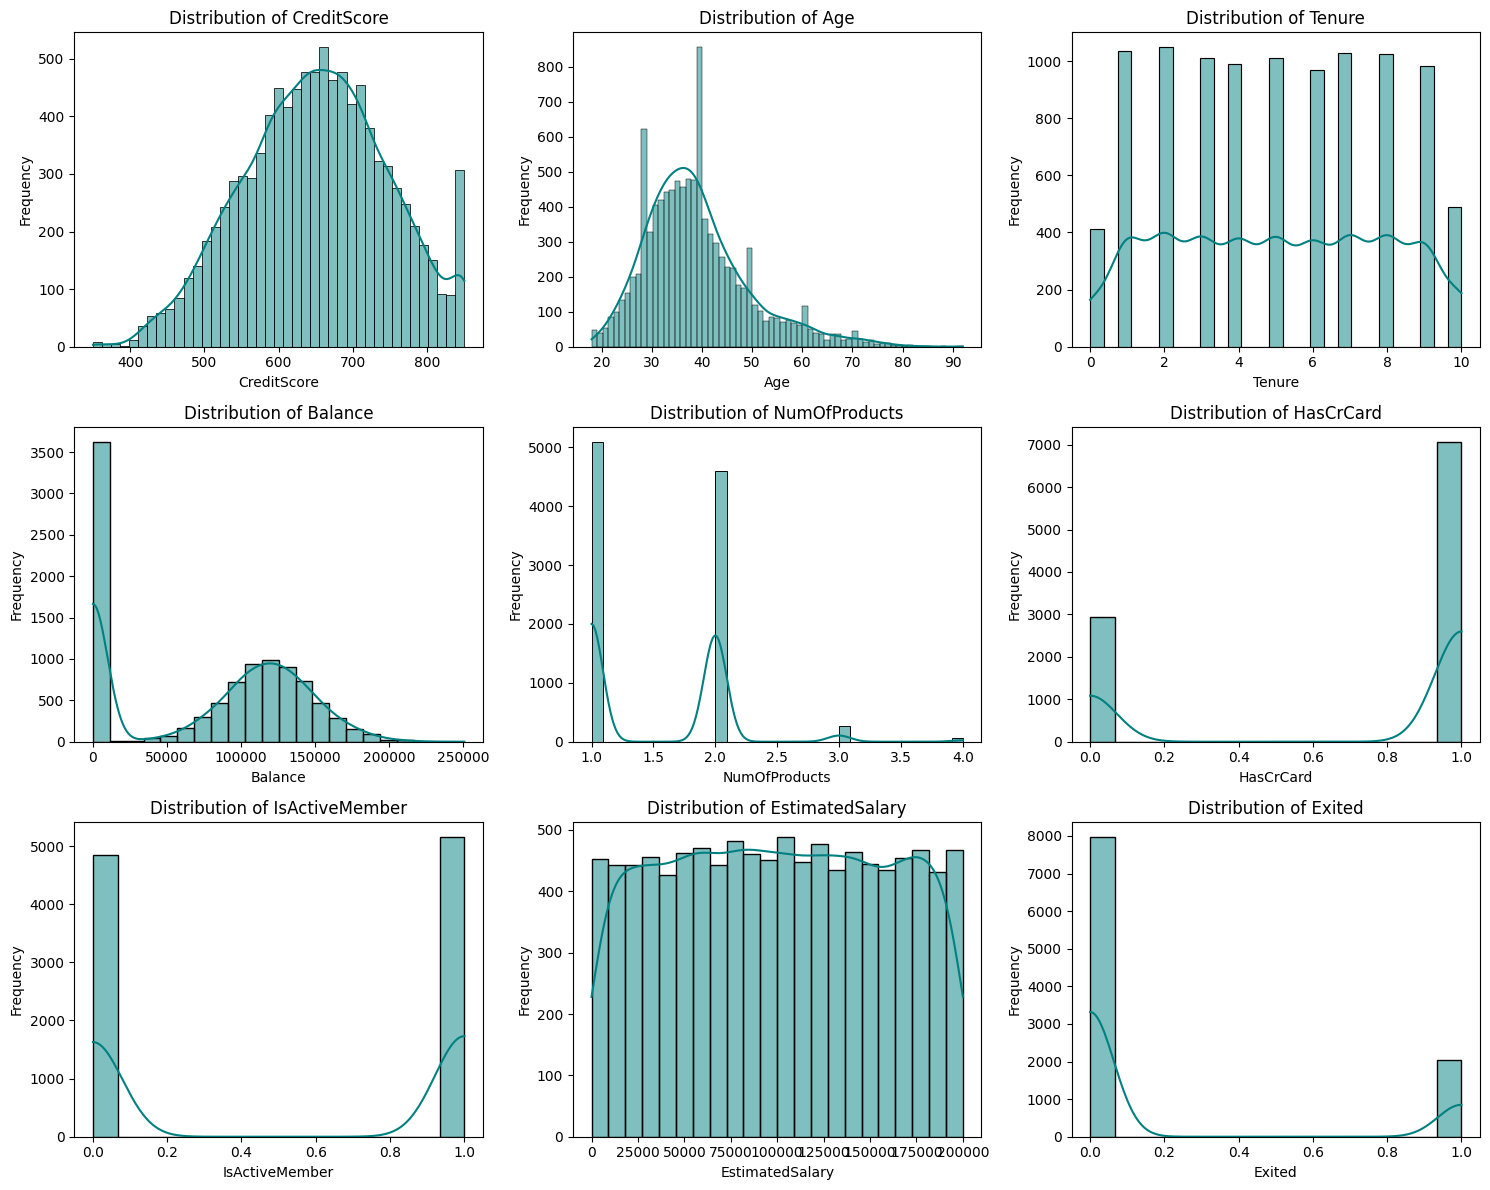

In [267]:
plot_distributions(df)

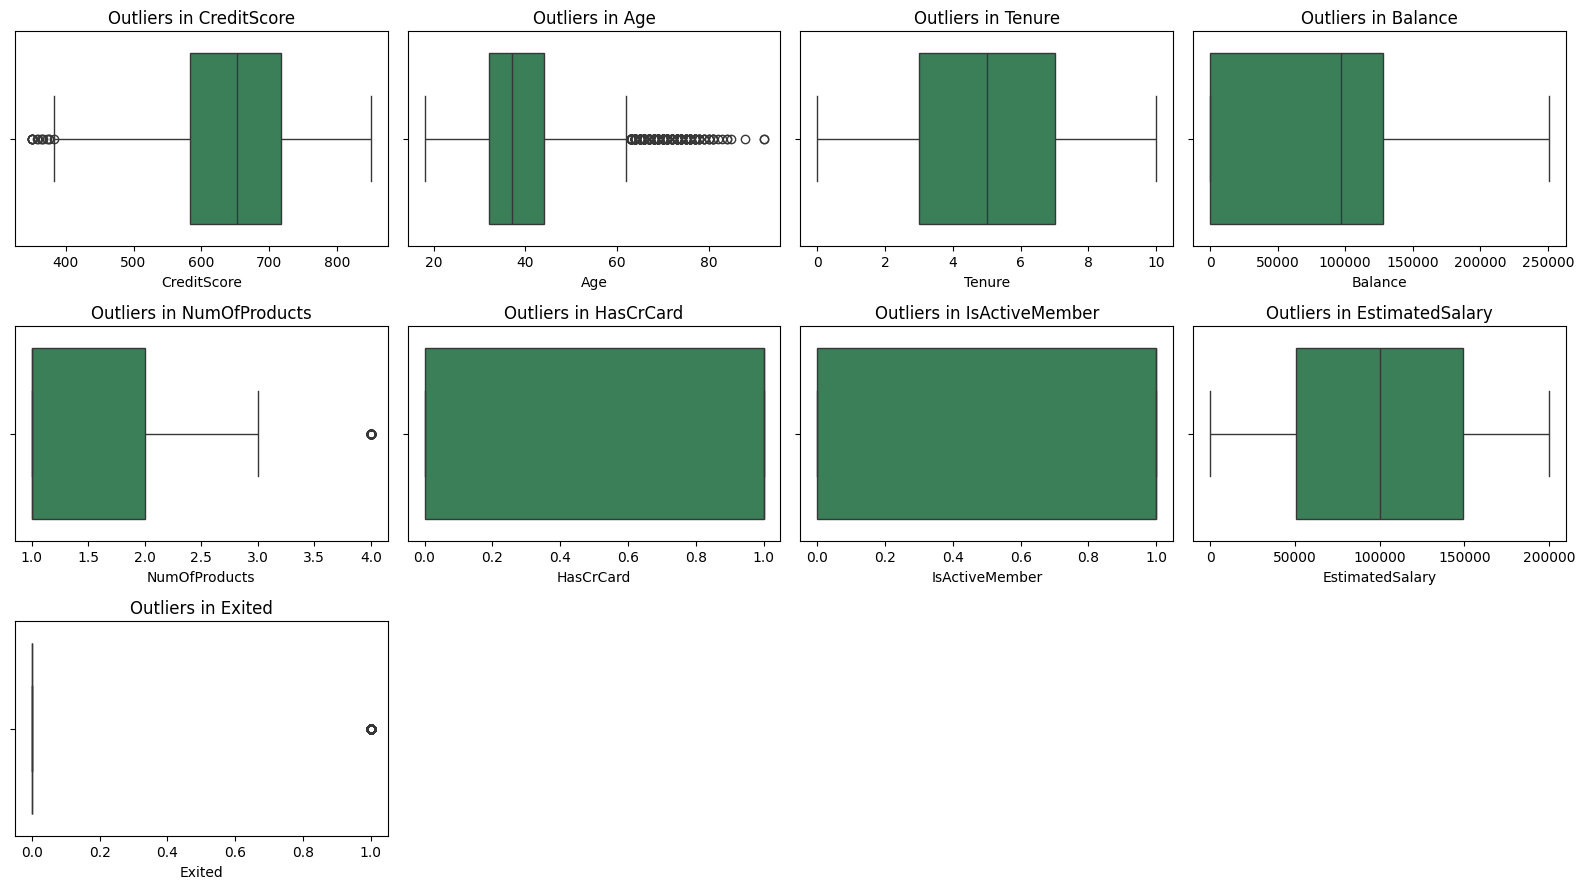

In [268]:
plot_outliers(df)

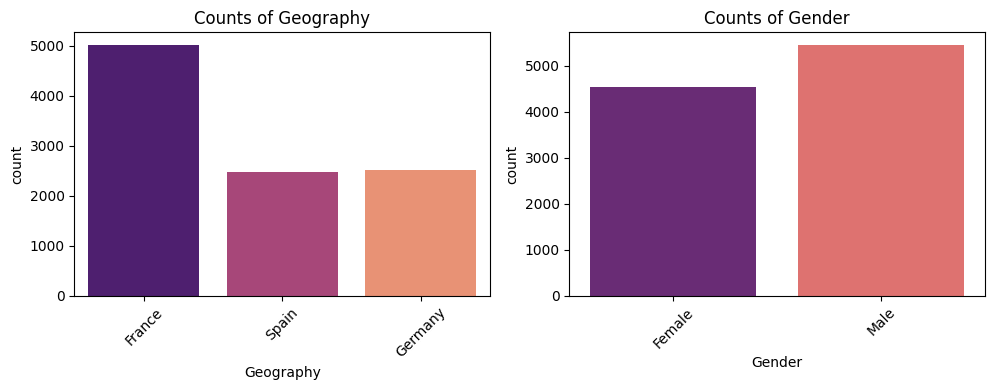

In [269]:
plot_categoricals(df)

--- Class Distribution ---
Exited
0    7963
1    2037
Name: count, dtype: int64

--- Percentage ---
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


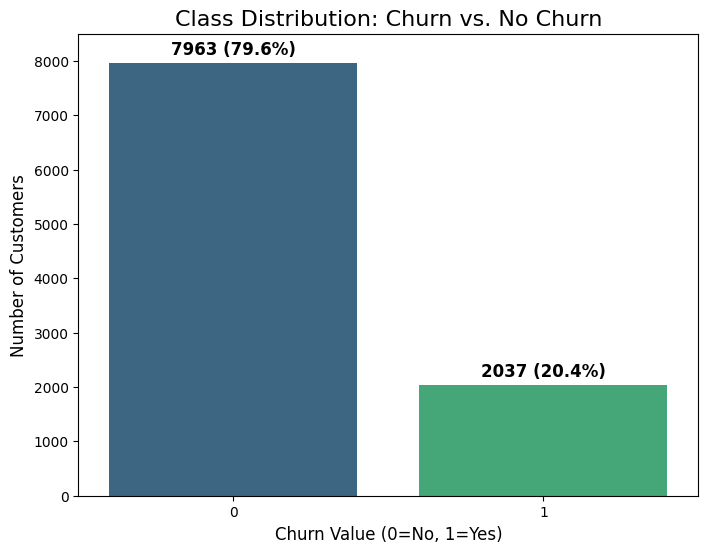

In [270]:
churn_counts = df['Exited'].value_counts()
churn_pct = df['Exited'].value_counts(normalize=True) * 100

print("--- Class Distribution ---")
print(churn_counts)
print("\n--- Percentage ---")
print(churn_pct)

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Exited', data=df, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.title('Class Distribution: Churn vs. No Churn', fontsize=16)
plt.xlabel('Churn Value (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.ylim(0, df.shape[0]*0.85) 
plt.show()

# 💡 Handling Outliers

In [271]:
columns_with_outliers = ['CreditScore', 'Age']
z_scores = np.abs((df[columns_with_outliers] - df[columns_with_outliers].mean()) / df[columns_with_outliers].std())
threshold = 2.5
df = df[(z_scores < threshold).all(axis=1)]

# 🛠️ Feature Engineering

In [272]:
bins = [0, 579, 669, 739, 799, 850]

labels = ['Poor', 'Fair', 'Good', 'Very Good', 'Exceptional']

df['Credit_Tier'] = pd.cut(df['CreditScore'], bins=bins, labels=labels)

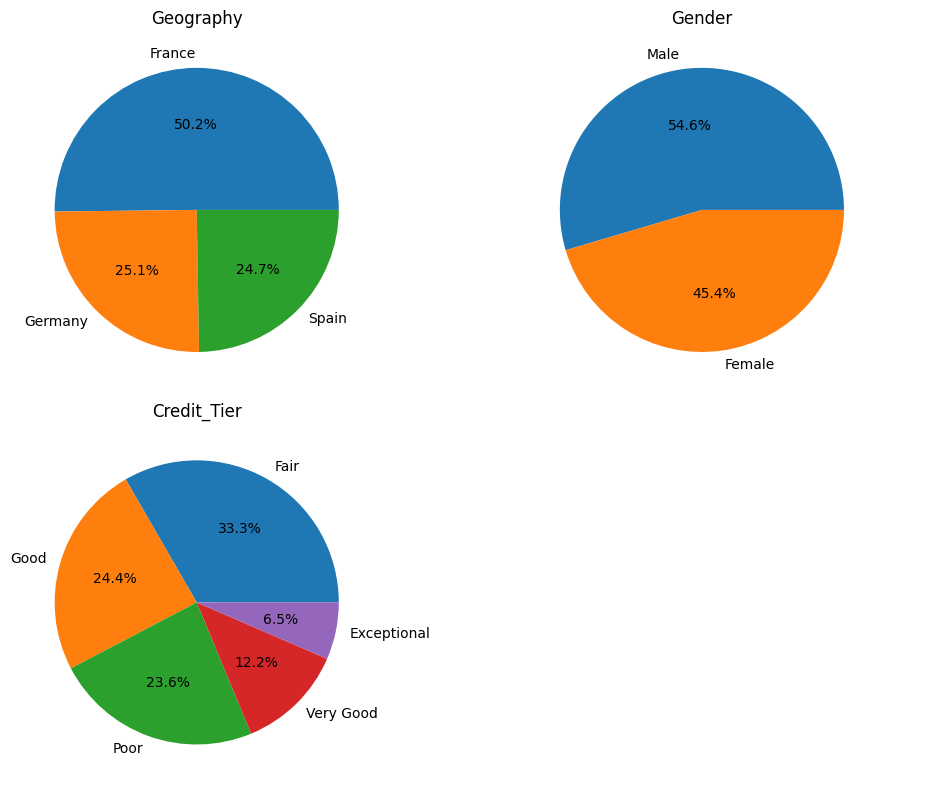

In [273]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

ax = ax.flatten()

df["Geography"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax[0])
ax[0].set_title("Geography")
ax[0].set_ylabel("") 

df["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax[1])
ax[1].set_title("Gender")
ax[1].set_ylabel("")

df["Credit_Tier"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax[2])
ax[2].set_title("Credit_Tier")
ax[2].set_ylabel("")

ax[3].axis('off')

plt.tight_layout() 
plt.show()

# 🔀 Encoding

In [274]:
df = pd.get_dummies(df, columns=['Geography'], drop_first=True, dtype=int)
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df["Credit_Tier"] = df["Credit_Tier"].map({'Poor':0, 'Fair':1, 'Good':2, 'Very Good':3, 'Exceptional':4}).astype(float)

# 🔗 Data Correlation

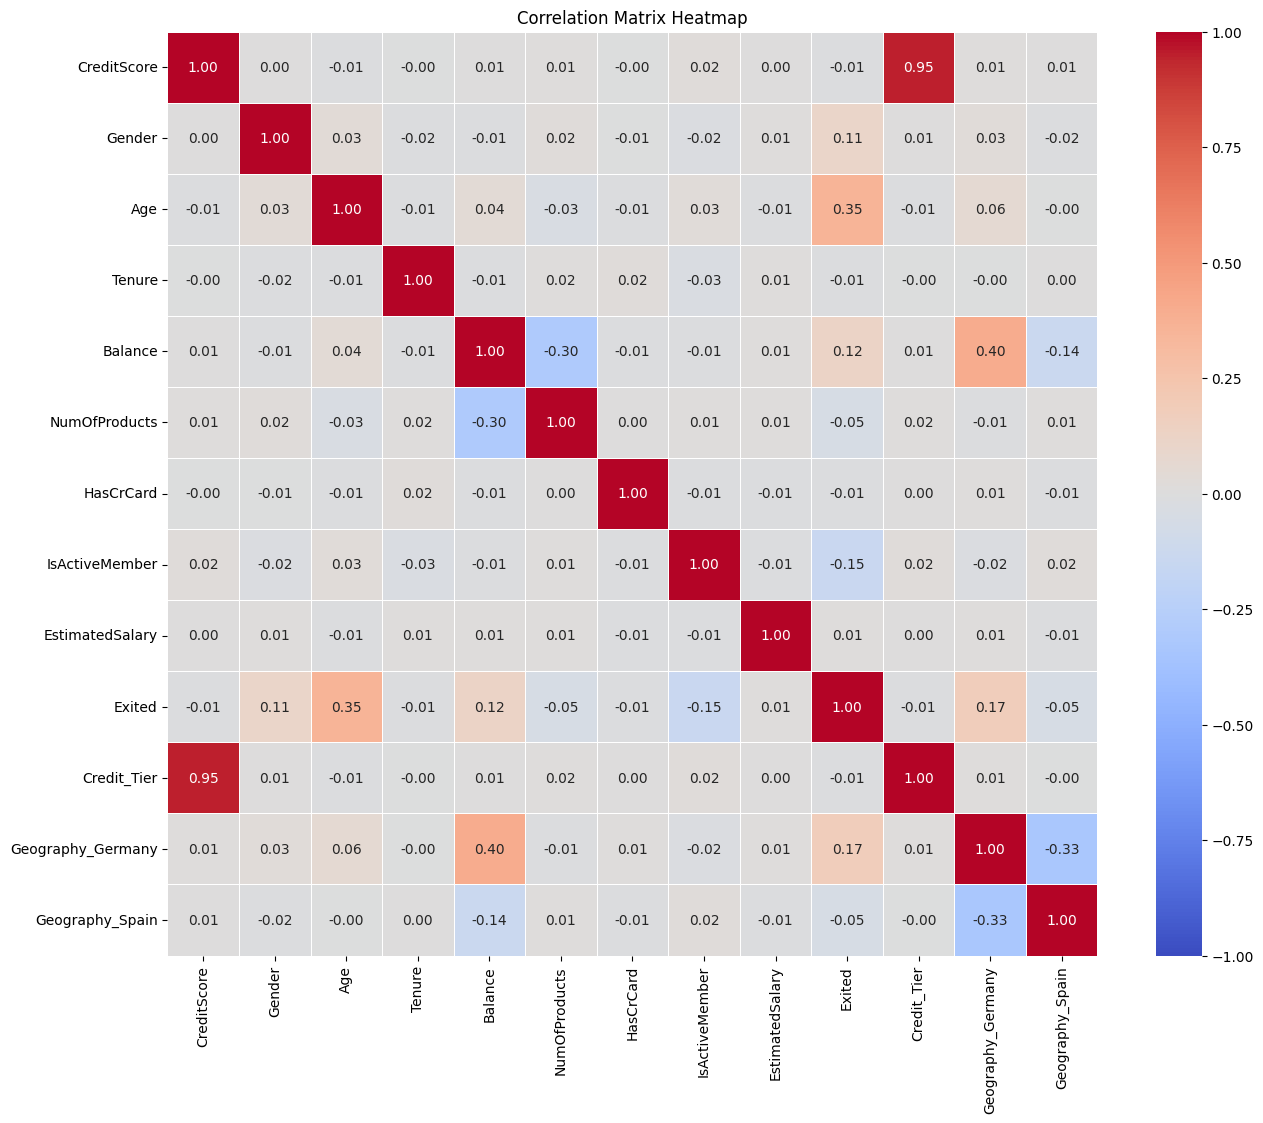


--- Correlation with Target: Exited ---
Exited               1.000000
Age                  0.354201
Geography_Germany    0.173121
Balance              0.117953
Gender               0.105812
EstimatedSalary      0.009142
HasCrCard           -0.008604
Credit_Tier         -0.012278
CreditScore         -0.012374
Tenure              -0.013855
NumOfProducts       -0.047648
Geography_Spain     -0.054214
IsActiveMember      -0.147162
Name: Exited, dtype: float64


In [275]:
plot_correlation(df,target_col="Exited")

# ✂️ Splitting Data

In [276]:
X = df.drop(columns=["Exited","CreditScore"])
y = df["Exited"]

x_train,x_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)

# 📏 Scaling Data

In [277]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# 🌟 Feature Improtance

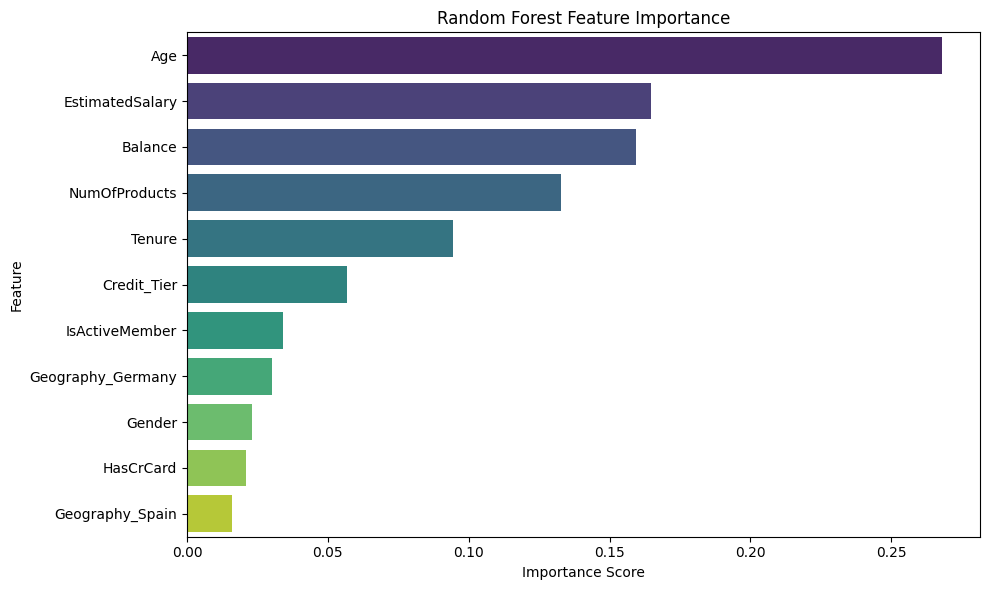

In [278]:
rf_importance_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_importance_model.fit(x_train, y_train)


feature_names = X.columns 

feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importance_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 3. Plot them beautifully
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 🧠 Model Archeticture & Training

In [279]:
xgb_best = XGBClassifier(
    subsample=1.0, scale_pos_weight=2, reg_lambda=0, reg_alpha=1, 
    n_estimators=900, max_depth=6, learning_rate=0.3, gamma=5, 
    colsample_bytree=0.9, use_label_encoder=False, eval_metric='logloss', random_state=42
)

rf_best = RandomForestClassifier(
    n_estimators=350, min_samples_split=5, min_samples_leaf=4, 
    max_features=None, max_depth=7, class_weight={0: 1, 1: 2}, 
    bootstrap=True, random_state=42, n_jobs=-1
)


voting_clf = VotingClassifier(
    estimators=[('xgb', xgb_best), ('rf', rf_best)],
    voting='soft',
    weights=[1,2]
)
voting_clf.fit(x_train, y_train)

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.9, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=5,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constr...
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=900, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('rf',
                              RandomForestClassifier(class_weight={0: 1, 1: 2},
                                                     max_depth=7,
                                                     max_features=None,
                                                     min_samples_leaf=4,
                                                     min_samples_split=5,
                                                     n_estimators=350,
                                                     n_jobs=-1,
                                                     random_state=42))],
                 voting='soft', weights=[1, 2])

# ⚖️ Testing

In [280]:
y_pred = voting_clf.predict(x_test)

# 📑 Classification Report

In [281]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      1547
           1       0.71      0.61      0.66       396

    accuracy                           0.87      1943
   macro avg       0.81      0.77      0.79      1943
weighted avg       0.86      0.87      0.87      1943



# 🧮 Confusion Matrix

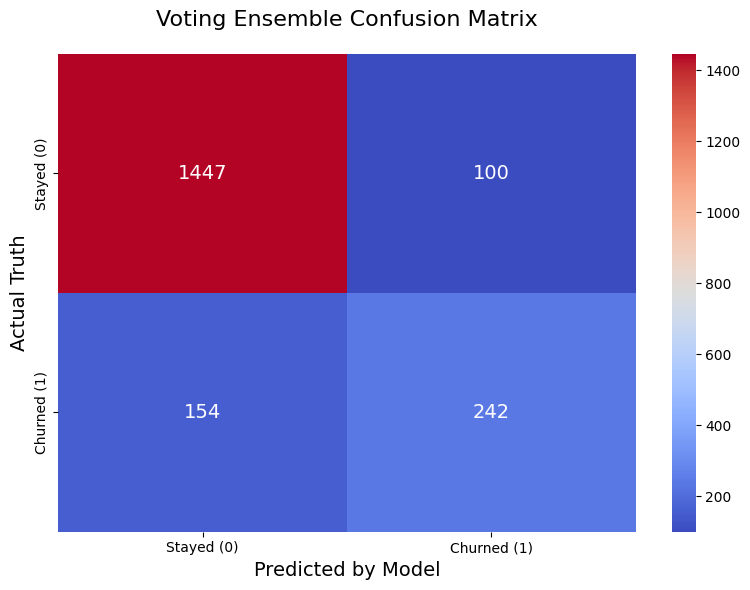

In [282]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', 
            xticklabels=['Stayed (0)', 'Churned (1)'], 
            yticklabels=['Stayed (0)', 'Churned (1)'],
            annot_kws={"size": 14})

plt.title('Voting Ensemble Confusion Matrix', fontsize=16, pad=20)
plt.xlabel('Predicted by Model', fontsize=14)
plt.ylabel('Actual Truth', fontsize=14)

plt.tight_layout()
plt.show()

# 💾 Saving Model

In [283]:
import joblib

joblib.dump(voting_clf, 'bank_churn_model.pkl')
joblib.dump(scaler, 'bank_churn_scaler.pkl')

print("✅ Model and Scaler successfully saved to disk!")

✅ Model and Scaler successfully saved to disk!
